# EXPLORING THE DATASET

In [58]:
## import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv("../data/card_transdata.csv")

## 01-General inspection and integrity
In this section, we inspect the dataset size, check for missing values and duplicates, and verify feature data types.

In [60]:
## read the first 5 rows of the dataset
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [61]:
## explore sizes of the dataset
df.shape

(1000000, 8)

In [62]:
## explore types of the dataset
df.dtypes

distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

In [63]:
## check for null values
df.isnull().sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [64]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

In [65]:
# Describe statistics for numerical columns in the dataset
df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


## 02 - Target Class Distribution & Imbalance Analysis

In this section, we analyze the distribution of the target variable (`fraud`) to measure the severity of class imbalance. This analysis helps determine the baseline accuracy and guide the choice of techniques (e.g., SMOTE, class weights, or undersampling) to handle imbalanced data effectively.

In [66]:
df["fraud"].value_counts()

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

<Axes: title={'center': 'Fraud vs Non-Fraud Transactions'}, xlabel='fraud'>

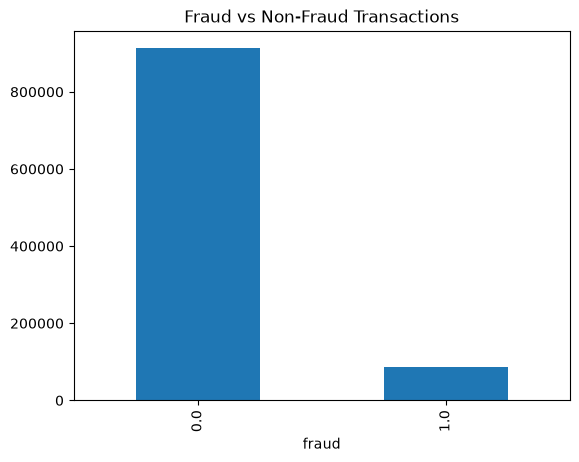

In [67]:
## plot the distribution of fraud and non-fraud transactions
df["fraud"].value_counts().plot(kind="bar", title="Fraud vs Non-Fraud Transactions")

## 03-Analysis of continuous variables
In this section, we examine continuous numerical features (`distance_from_home`, `distance_from_last_transaction`, `ratio_to_median_purchase_price`) to identify how their distributions differ between legitimate (`0`) and fraudulent (`1`) transactions.

In [68]:
continuous_cols = ["distance_from_home", "distance_from_last_transaction", "ratio_to_median_purchase_price"]
df[continuous_cols].skew()

distance_from_home                 20.239733
distance_from_last_transaction    125.921226
ratio_to_median_purchase_price      8.915015
dtype: float64

### Key Insights on Feature Skewness & Scaling Implications:

* **Extreme Right Skewness:** All continuous variables (`distance_from_home`, `distance_from_last_transaction`, `ratio_to_median_purchase_price`) exhibit extreme right-skewness (skew > 1.0).
* **Data Transformation Needed:** Standard scaling (`StandardScaler`) will be heavily distorted by extreme values. A logarithmic transformation (`np.log1p`) or `RobustScaler` (IQR-based) will be required for linear algorithms and distance-based models (e.g., Logistic Regression, KNN).
* **Tree-Based Models:** Tree algorithms (e.g., Random Forest, XGBoost) remain invariant to monotonic transformations, but log scaling will help improve data visualization and feature stability.

In [69]:
from sklearn.preprocessing import RobustScaler,PowerTransformer,QuantileTransformer
pt = PowerTransformer(method='yeo-johnson')
qt = QuantileTransformer(output_distribution='normal')
rs = RobustScaler()

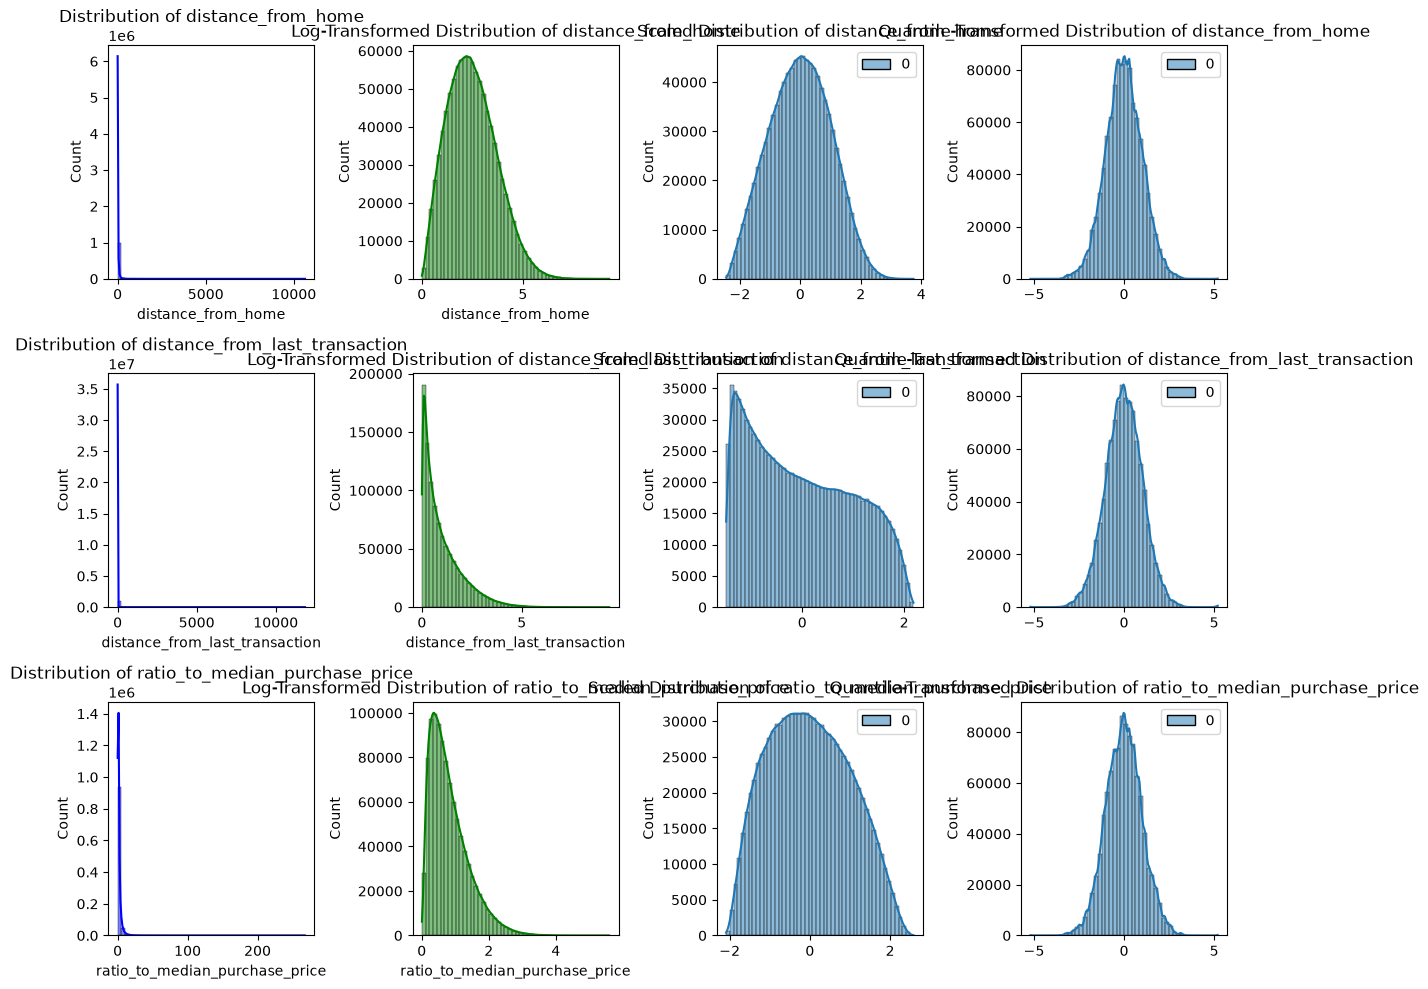

In [73]:
## plot the distribution of continuous features before and after transformation
cont_features = ["distance_from_home", "distance_from_last_transaction", "ratio_to_median_purchase_price"]

fig, axes = plt.subplots(len(cont_features), 4, figsize=(12, 10))
for i, feature in enumerate(cont_features):
    sns.histplot(df[feature], bins=50, ax=axes[i, 0], kde=True, color='blue')
    axes[i,0].set_title(f'Distribution of {feature}')
    
    log_transformed = np.log1p(df[feature])
    sns.histplot(log_transformed, bins=50, ax=axes[i, 1], kde=True, color='green')
    axes[i,1].set_title(f'Log-Transformed Distribution of {feature}')

 
    scaled_feature = pt.fit_transform(df[feature].values.reshape(-1, 1))
    sns.histplot(scaled_feature, bins=50, ax=axes[i, 2], kde=True, color='orange')
    axes[i,2].set_title(f'Scaled Distribution of {feature}')    

    sf = qt.fit_transform(df[feature].values.reshape(-1, 1))
    sns.histplot(sf, bins=50, ax=axes[i, 3], kde=True, color='purple')
    axes[i,3].set_title(f'Quantile-Transformed Distribution of {feature}')

    

plt.tight_layout()
plt.show()

### 

### Selection Justification: QuantileTransformer

Based on the comparative distribution analysis, **`QuantileTransformer(output_distribution='normal')`** is selected for preprocessing continuous features due to the following criteria:

* **Handling Extreme Skew & Zero Inflation:** Successfully transforms highly skewed distributions—specifically resolving the zero-inflation flattening in `distance_from_last_transaction` where `np.log1p` fell short—into symmetric Gaussian curves.
* **Robustness to Outliers:** Maps features based on percentiles, neutralizing the distortive effect of extreme transaction distances without dropping valid data points.
* **Uniform Feature Scaling:** Standardizes all continuous inputs into a normalized range ($\approx [-3, 3]$ centered at $0$), ensuring optimal gradient convergence for distance-based and linear algorithms (e.g., Logistic Regression, KNN, Neural Networks).

Text(0.5, 1.0, 'Correlation Heatmap')

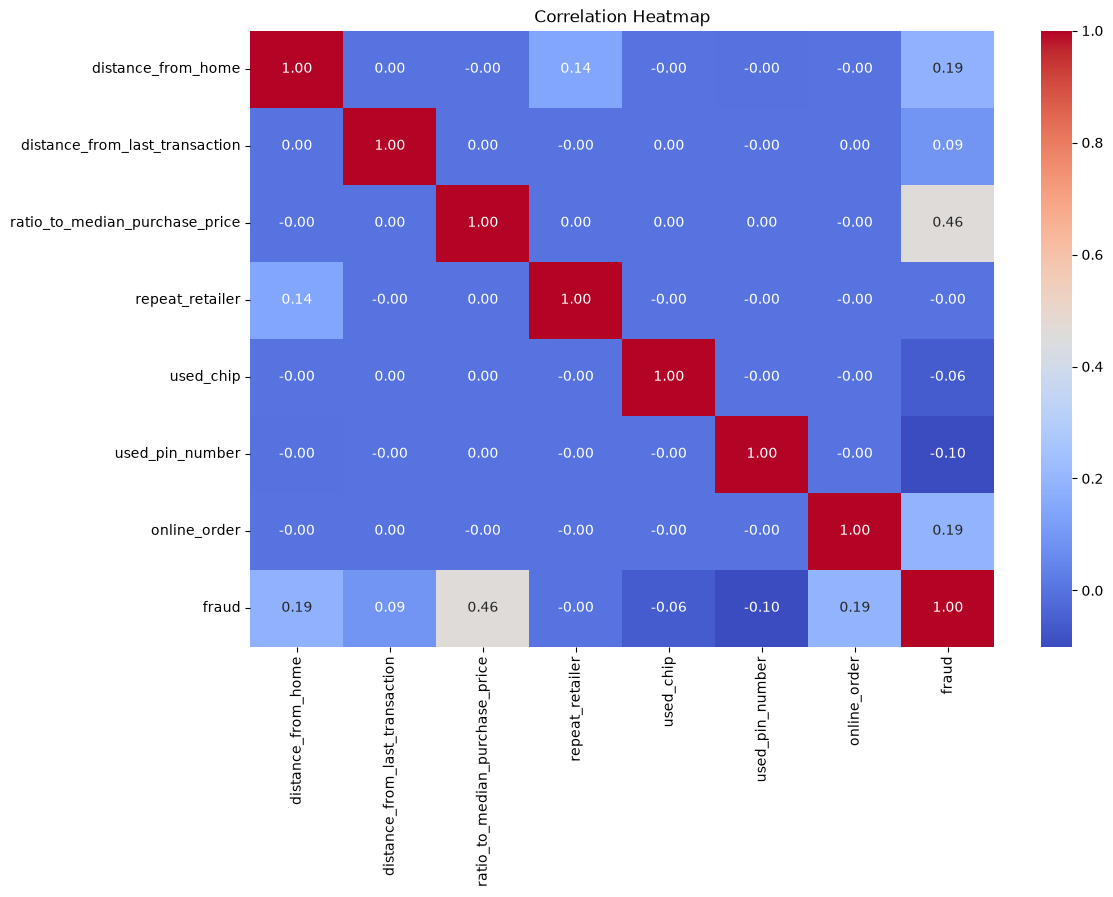

In [74]:
## HEATMAP
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")    

#### **Looking at the heat map, the 7 variables are preserved**

## THANKS FOR YOU ATTENTION!!